## Dataset Loading

In [ ]:
import pandas as pd

pd.set_option("display.max_columns", None)  # 1. stop the "..." truncation block
pd.set_option("display.width", 160)  # 2. chars per line before wrapping  <- tune this
pd.set_option("display.expand_frame_repr", True)  # 3. allow wrap to next line (default)
pd.set_option("display.max_colwidth", 40)   # 4. keep long strings from blowing up width

DATA_PATH = "data/AB Testing Data.csv"
df = pd.read_csv(DATA_PATH)

print("SHAPE: ")
print(df.shape,'\n')
print("INFO: ")
print(df.head(),'\n')
print("COLUMNS: ")
print(df.columns.tolist(),'\n')

## Data Understanding

In [2]:
print("Shape: ",df.shape)

print("\nColumns: ")
print(df.columns.tolist())

print("\nData Types: ")
print(df.dtypes)

print("\nFirst 5 rows: ")
print(df.head())

print("\nSummary: ")
print(df.describe(include='all'))

Shape:  (294478, 12)

Columns: 
['user_id', 'timestamp', 'group', 'landing_page', 'converted', 'age', 'gender', 'location', 'session_duration', 'pages_visited', 'device_type', 'purchase_amount']

Data Types: 
user_id                 str
timestamp               str
group                   str
landing_page            str
converted             int64
age                   int64
gender                  str
location                str
session_duration    float64
pages_visited         int64
device_type             str
purchase_amount     float64
dtype: object

First 5 rows: 
  user_id                   timestamp      group landing_page  converted  age  gender   location  session_duration  pages_visited device_type  purchase_amount
0      U1  2025-08-02 15:27:54.137058    control     old_page          0   37    Male   Pakistan              3.69              4      Mobile              0.0
1      U2  2024-04-22 10:22:51.712050  treatment     new_page          0   31  Female         UK           

## Data Quality Checks

### .1 Missing values

In [3]:
missing = df.isna().sum().sort_values(ascending=False)

print(missing)

user_id             0
timestamp           0
group               0
landing_page        0
converted           0
age                 0
gender              0
location            0
session_duration    0
pages_visited       0
device_type         0
purchase_amount     0
dtype: int64


### .2 Duplicate rows

In [4]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


### .3 Unique values

In [ ]:
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).head(20))

## Identify the experiment groups

In [7]:
print(df["group"].value_counts())

GROUP_COL = "group"

CONTROL = "control"
TREATMENT = "treatment"

group
treatment    147552
control      146926
Name: count, dtype: int64


In [8]:
print(pd.crosstab(df["group"], df["landing_page"]))

landing_page  new_page  old_page
group                           
control              0    146926
treatment       147552         0


## Calculate Sample Sizes

In [9]:
control = df[df["group"] == "control"]
treatment = df[df["group"] == "treatment"]

n_control = len(control)
n_treatment = len(treatment)

print("Control sample size:", n_control)
print("Treatment sample size:", n_treatment)

Control sample size: 146926
Treatment sample size: 147552


## Check conversion rules

In [14]:
print(df["converted"].value_counts().sort_index())
non_conversion = df["converted"].value_counts()[0]
conversion = df["converted"].value_counts()[1]
print()
print("Non-conversions: ", non_conversion)
print("Conversions: ", conversion)

converted
0    250550
1     43928
Name: count, dtype: int64

Non-conversions:  250550
Conversions:  43928


## Calculate conversions in each group

In [19]:
x_control = control["converted"].sum()
x_treatment = treatment["converted"].sum()

print("Control conversions:", x_control)
print("Treatment conversions:", x_treatment)

Control conversions: 17444
Treatment conversions: 26484


## Calculate conversion rates

In [20]:
p_control = x_control / n_control
p_treatment = x_treatment / n_treatment

print(f"Control: {p_control:.4%}")
print(f"Treatment: {p_treatment:.4%}")

Control: 11.8726%
Treatment: 17.9489%


## Calculate absolute difference

In [21]:
absolute_difference = p_treatment - p_control

print(f"{absolute_difference:.4%}")

6.0763%


## Calculate relative lift

In [22]:
relative_lift = (p_treatment - p_control) / p_control

print(f"{relative_lift:.4%}")

51.1789%


In [23]:
p_treatment / p_control

np.float64(1.5117885645628424)

H₀

There is no difference between the control and treatment conversion rates.

$$ H_0:p_T=p_C $$

H₁

There is a difference between the control and treatment conversion rates.

$$H_1:p_T!=p_C$$
	​


## Check sample balance

In [24]:
print(n_treatment / n_control)

1.00426064821747


## Check statistical-test assumptions

Binary outcome

Expected:

converted = {0, 1}

PASS.

Two independent groups

Expected groups:

control
treatment

PASS, assuming the dataset's experimental design treats each user as an independent observation.

Duplicate users

Expected:

0

PASS.

Adequate expected counts

Under the pooled null proportion, expected counts are approximately:

Group	Expected Non-conversions	Expected Conversions
Control	125,008.69	21,917.31
Treatment	125,541.31	22,010.69

All are far above 5.

PASS.

Important limitation

The dataset itself does not prove that users were randomly assigned. You can verify the group/page mapping, but randomization should be treated as a property of the experiment design rather than something inferred solely from the CSV.

Record:

Random assignment could not be independently verified from the dataset alone.

## Perform the two-proportion z-test

In [25]:
from statsmodels.stats.proportion import proportions_ztest

count = [x_treatment, x_control]
nobs = [n_treatment, n_control]

z_stat, p_value = proportions_ztest(count, nobs, alternative="two-sided")

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: 46.277339891305736
P-value: 0.0


The p-value is not literally zero.

It is approximately:
1.57×10−467

## Chi-Square cross check

In [26]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["group"], df["converted"])

chi2, p, dof, expected = chi2_contingency(table, correction=False)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square: 2141.5921874154365
p-value: 0.0
Degrees of freedom: 1


## Confidence intervals for conversion rates

In [33]:
from statsmodels.stats.proportion import proportion_confint

control_ci = proportion_confint(x_control, n_control, alpha=0.05, method="wilson")

treatment_ci = proportion_confint(x_treatment, n_treatment, alpha=0.05, method="wilson")

print(control_ci)
print(treatment_ci)

(0.1170824228051942, 0.12039038130587308)
(0.17753950743966904, 0.18145571047316347)


## Confidence interval for the difference

In [34]:
from statsmodels.stats.proportion import confint_proportions_2indep

difference_ci = confint_proportions_2indep(
    count1=x_treatment,
    nobs1=n_treatment,
    count2=x_control,
    nobs2=n_control,
    compare="diff",
    method="newcomb",
    alpha=0.05,
)

print(difference_ci)

(np.float64(0.0581995762503615), np.float64(0.06332596987543909))


## Effect size

In [36]:
import numpy as np
h = 2 * np.arcsin(np.sqrt(p_treatment)) - 2 * np.arcsin(np.sqrt(p_control))

print(h)

0.17141288291211465


## Statistical significance

Treatment rate = 17.95%
Control rate   = 11.87%

Difference     = +6.08 percentage points

Z              = 46.2773

p-value        < 0.001

Therefore:

Reject H₀ at the 5% significance level.

## Visualizations

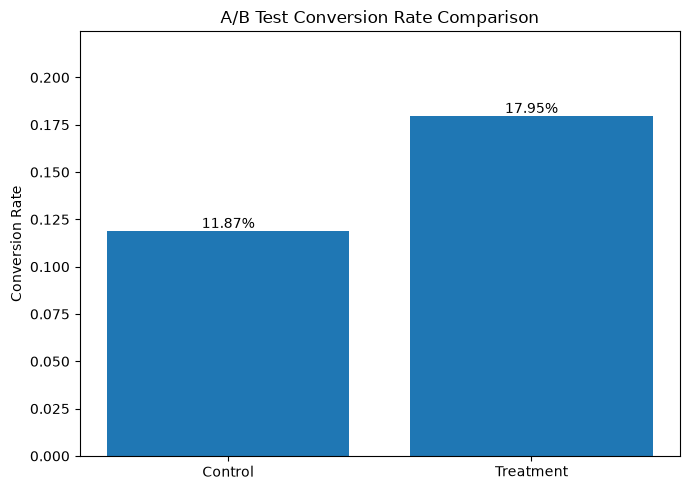

In [38]:
import matplotlib.pyplot as plt
rates = [p_control, p_treatment]
labels = ["Control", "Treatment"]

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, rates)

plt.ylabel("Conversion Rate")
plt.title("A/B Test Conversion Rate Comparison")
plt.ylim(0, max(rates) * 1.25 if max(rates) > 0 else 1)

for bar, rate in zip(bars, rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.2%}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()